## Simulating Par 4

### Outline of Process

#### Goal
Going to pull back the par 3 to convert it into a Par 4 in order to maintain green. Play with placement of a large lake to see how that impacts our simulation.

### Bits
##### Short Game
Under 75 Yards model the GPR:
1. Green Data -> as defined from our modelled putts GPR
2. Other -> 
    - Use Broadie Estimates and Interpolate

##### Approach
At 5 yard intervals:
- Act like its the teebox,
 - Evaluate optimal aimpoint / club combination for:
 1. Club whose average is closest to the euclidean distance between the start and target (hole)
 2. Club above and below

##### Tee Shots
Run relative to the centre of the fair way:
- 8 iron -> Driver, want to maximise:
$$Opt_{tee} = \argmin (\frac{1}{m} \sum ^M_{i=1}Opt_i)$$

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely import wkt
from shapely.geometry import Point


In [3]:
hole_9 = pd.read_csv("/Users/federicadomecq/Documents/golfModeL47-1/PART 1/Map Digitisation/Mountain Meadows/MountainMeadows_Separated/hole_9/hole_9_data.csv")

hole = (5, 174)

hole_9["geometry"] = hole_9["WKT"].apply(wkt.loads)

def get_centroid(row):
    shape = wkt.loads(row["WKT"])
    return shape.centroid.coords[0] # returns the x,y coords

# finding furthest teebox
teeboxes = hole_9[hole_9["lie"].str.contains("tee", case = False)]
green = hole_9[hole_9["lie"] == "green"].iloc[0]
green_shape = wkt.loads(green["WKT"])
green_centre = get_centroid(green)
# getting different teeboxes centre
teeboxes["centroid"] = teeboxes.apply(get_centroid, axis=1) #axis 1 passes a row instead of column

# distances to green
teeboxes["dist_to_green"] = teeboxes["centroid"].apply(
    # np.array(pt) - np.array(green_centre) -> subtracts the two 2d points, and linalg compute the euclidean distance
    lambda pt: np.linalg.norm(np.array(pt) - np.array(green_centre))
)

longest_teebox = teeboxes.loc[teeboxes["dist_to_green"].idxmax()]
tee_point = longest_teebox["centroid"]

## ------------- Extension
gdf = gpd.read_file("/Users/federicadomecq/Documents/golfModeL47-1/PART 3 / Simulating Par 4/newshapes.geojson")

# Filter by terrain type
new_fairway = gdf[gdf["lie"] == "fairway"]
new_hazard1 = gdf[gdf["lie"] == "water_hazard_1"]
new_hazard2 = gdf[gdf["lie"] == "water_hazard_2"]
new_hazard3 = gdf[gdf["lie"] == "water_hazard_3"]

#converting to metres
new_fairway = new_fairway.to_crs(epsg=32611)
new_hazard1 = new_hazard1.to_crs(epsg=32611)
new_hazard2 = new_hazard2.to_crs(epsg=32611)
new_hazard3 = new_hazard3.to_crs(epsg=32611)

# Convert to shapely for simulation
fairway_shapes2 = new_fairway["geometry"].tolist()
water_shape1 = new_hazard1["geometry"].tolist()
water_shape2 = new_hazard2["geometry"].tolist()
water_shape3 = new_hazard3["geometry"].tolist()


/var/folders/vr/34gvhdpn06z_plwsw13j8w4c0000gn/T/ipykernel_72810/745864115.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  teeboxes["centroid"] = teeboxes.apply(get_centroid, axis=1) #axis 1 passes a row instead of column
/var/folders/vr/34gvhdpn06z_plwsw13j8w4c0000gn/T/ipykernel_72810/745864115.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  teeboxes["dist_to_green"] = teeboxes["centroid"].apply(


In [4]:
# weird fix
from shapely.affinity import translate

# Get the centroid of the new fairway (in lat/lon)
ref_centroid = new_fairway.iloc[0].geometry.centroid
print("Original fairway centroid:", ref_centroid)

#  target location — 
target_x, target_y = 0, 100

# Calculate the amount to shift
x_shift = target_x - ref_centroid.x
y_shift = target_y - ref_centroid.y
print(f"Shifting by x: {x_shift:.4f}, y: {y_shift:.4f}")

# Apply the shift to all geometries
def shift_geometry(geom):
    return translate(geom, xoff=x_shift, yoff=y_shift)

new_fairway["geometry"] = new_fairway["geometry"].apply(shift_geometry)
new_hazard1["geometry"] = new_hazard1["geometry"].apply(shift_geometry)
new_hazard2["geometry"] = new_hazard2["geometry"].apply(shift_geometry)
new_hazard3["geometry"] = new_hazard3["geometry"].apply(shift_geometry)

# ---------- rotating shapes - to be in the same direction as hole

from shapely.affinity import rotate

# Get the bounds of the fairway polygon
fairway_poly = new_fairway.iloc[0].geometry
minx, miny, maxx, maxy = fairway_poly.bounds

# Get two points to define direction
start = np.array([fairway_poly.centroid.x, miny])  # bottom
end = np.array([fairway_poly.centroid.x, maxy])    # top

# Direction vector
vec = end - start

# Angle with respect to the y-axis (0, 1)
angle_rad = np.arctan2(vec[0], vec[1])  # we flip x and y to get angle from y-axis
angle_deg = np.degrees(angle_rad)

def rotate_geometry(geom, angle, origin="centroid"):
    return rotate(geom, angle=-angle, origin=origin, use_radians=False)

# Apply rotation
rotation_angle = angle_deg  # from step 1 above
new_fairway["geometry"] = new_fairway["geometry"].apply(rotate_geometry, args=(rotation_angle,))
new_hazard1["geometry"] = new_hazard1["geometry"].apply(rotate_geometry, args=(rotation_angle,))
new_hazard2["geometry"] = new_hazard2["geometry"].apply(rotate_geometry, args=(rotation_angle,))
new_hazard3["geometry"] = new_hazard3["geometry"].apply(rotate_geometry, args=(rotation_angle,))


Original fairway centroid: POINT (428316.7204142687 3771582.6458220687)
Shifting by x: -428316.7204, y: -3771482.6458


In [5]:
#  downstream shapes (green, bunkers, existing water hazard) -> shifting up
shift_targets = hole_9[hole_9["lie"].isin(["green", "bunker", "water_hazard", "fairway"])].copy()

y_shift = 160

hole = (5, 174 + y_shift)

def shift_wkt(wkt_str):
    shape = wkt.loads(wkt_str)
    return translate(shape, yoff=y_shift)

# Apply shift
hole_9.loc[shift_targets.index, "WKT"] = shift_targets["WKT"].apply(shift_wkt).apply(lambda g: g.wkt)

In [6]:
from shapely.affinity import translate, rotate

# --- Fairway extension ----------------------
fairway_centroid = new_fairway.iloc[0].geometry.centroid
target_x, target_y = 20, 175
x_shift = target_x - fairway_centroid.x
y_shift = target_y - fairway_centroid.y

new_fairway["geometry"] = new_fairway["geometry"].apply(
    lambda geom: translate(geom, xoff=x_shift, yoff=y_shift)
)

new_fairway["geometry"] = new_fairway["geometry"].apply(
    lambda geom: rotate(geom, angle=-68, origin="centroid", use_radians=False)
)

# --- Hazard 3 addition --------------
hazard3_centroid = new_hazard3.iloc[0].geometry.centroid
target_x3, target_y3 = 0, 230
x3_shift = target_x3 - hazard3_centroid.x
y3_shift = target_y3 - hazard3_centroid.y

new_hazard3["geometry"] = new_hazard3["geometry"].apply(
    lambda geom: translate(geom, xoff=x3_shift, yoff=y3_shift)
)

new_hazard3["geometry"] = new_hazard3["geometry"].apply(
    lambda geom: rotate(geom, angle=110, origin="centroid", use_radians=False)
)


<Axes: title={'center': 'Par 4 Strategy Layout'}>

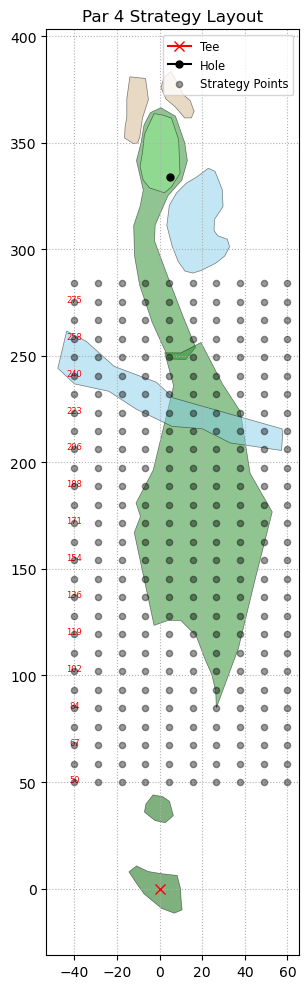

In [7]:
import matplotlib.pyplot as plt
from shapely import wkt


# for plotting where the approach shots are evaluated
hole_vec = np.array(hole)
tee_vec= np.array(tee_point)
hole_to_tee_vec = hole_vec - tee_vec
ht_length = np.linalg.norm(hole_to_tee_vec)

# Grid parameters
x_vals = np.linspace(-40, 60, int(100 / 10 ) ) # evaluating at 10 yard intervals
y_vals = np.linspace(50, ht_length - 50, int((ht_length - 50) / 10 ))

strategy_points = [(x, y) for y in y_vals for x in x_vals]

def plot_hole_layout(hole_geom_df, new_fairway=None, new_hazards=None,
                     tee_point=None, hole_point=None, fairway_grid=None,
                     title="Hole Layout", figsize=(10, 10), lie_colors=None, plot_approach = True):

    if lie_colors is None:
        lie_colors = {
            "bunker": "tan",
            "fairway": "forestgreen",
            "new_fairway": "forestgreen",
            "green": "lightgreen",
            "OB": "lightcoral",
            "rough": "mediumseagreen",
            "tee": "darkgreen",
            "water_hazard": "skyblue",
            "new_hazard1": "skyblue",
            "new_hazard2": "skyblue",
            "new_hazard3": "skyblue"
        }

    fig, ax = plt.subplots(figsize=figsize)

    # Base geometry (from WKT)
    for _, row in hole_geom_df.iterrows():
        geom = wkt.loads(row["WKT"])
        color = lie_colors.get(row["lie"], "lightgrey")

        if geom.geom_type == "Polygon":
            x, y = geom.exterior.xy
            ax.fill(x, y, alpha=0.5, fc=color, edgecolor="black", linewidth=0.5)
        elif geom.geom_type == "MultiPolygon":
            for poly in geom.geoms:
                x, y = poly.exterior.xy
                ax.fill(x, y, alpha=0.5, fc=color, edgecolor="black", linewidth=0.5)

    # Optional new fairway
    if new_fairway is not None:
        for _, row in new_fairway.iterrows():
            x, y = row["geometry"].exterior.xy
            ax.fill(x, y, alpha=0.5, fc=lie_colors["new_fairway"], edgecolor="black", linewidth=0.5)

    # Optional new hazards
    if new_hazards:
        for i, hazard_df in enumerate(new_hazards, start=1):
            key = f"new_hazard{i}"
            if key in lie_colors:
                for _, row in hazard_df.iterrows():
                    x, y = row["geometry"].exterior.xy
                    ax.fill(x, y, alpha=0.5, fc=lie_colors[key], edgecolor="black", linewidth=0.5)

    # Tee + Hole
    if tee_point:
        ax.plot(tee_point[0], tee_point[1], marker='x', color='red', markersize=7, label="Tee")
    if hole_point:
        ax.plot(hole_point[0], hole_point[1], marker='o', color='black', markersize=5, label="Hole")

    if plot_approach:
        ax = plt.gca()
        # Plot points
        xs, ys = zip(*strategy_points)
        ax.scatter(xs, ys, color='black', s=20, label="Strategy Points", zorder=10, alpha= .4)

        # Optional: label some for visual debug
        for x, y in strategy_points[::20]:
            ax.text(x, y, f"{int(y)}", fontsize=6, color='red', ha='center')

        ax.legend()
        plt.draw()

    ax.set_aspect("equal")
    ax.set_title(title)
    ax.legend(loc="upper right", fontsize="small")
    ax.grid(True, linestyle=':')
    plt.tight_layout()
    #plt.show()
    return ax

plot_hole_layout(
    hole_geom_df=hole_9,
    new_fairway=new_fairway,
    new_hazards=[new_hazard3],
    tee_point=tee_point,
    hole_point=hole,
    title="Par 4 Strategy Layout",
    plot_approach= True
)


# Evaluating Optimal Strategy at different points

*target* - always hole, all aims relative to the hole

*clubs to evaluate* - get the distance from `starting pos` to `target`, `dist_hole`:
- our middle - club whose $\mu_d$ is closest to `dist_hole`
- we evaluate: `[middle - 2, middle - 1, middle, middle + 1, middle +2]`

*aiming offsets* - anywhere `[-20, 20]` relative to the pin

*starting pos*:
- if on fairway, just simulate from the point
- if in water: 
    - drop back along the line of entry, evaluate at the border from ``rough"
- if in rough:
    - should 
        - make the mean a little smaller and increase the variance


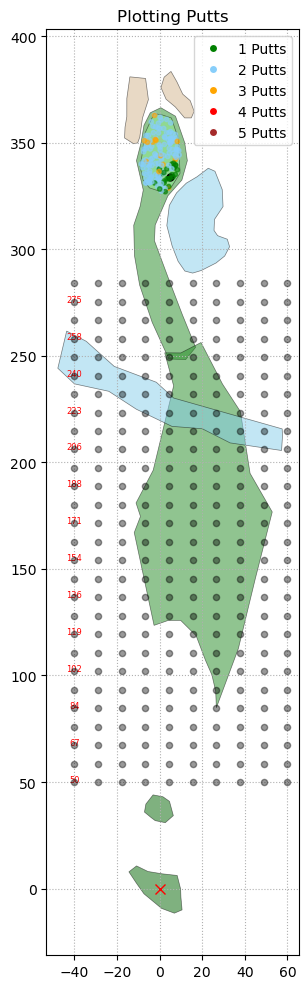

In [8]:
putts_og_loc = pd.read_csv("/Users/federicadomecq/Documents/golfModeL47-1/PART 3 / Simulating Par 4/gpr_green_dataset.csv")

shifted_putts = putts_og_loc.copy()
shifted_putts["y"] = shifted_putts["y"] + 160

def plot_putts(putts_df, alpha=0.6, zorder=15):
    xs = putts_df["x"].values
    ys = putts_df["y"].values
    strokes = putts_df["simulated_strokes"].astype(int).values

    putt_color_map = {
        1: "green",
        2: "lightskyblue",
        3: "orange",
        4: "red",
        5: "brown"
    }
    default_color = "purple"

    plot_hole_layout(
    hole_geom_df=hole_9,
    new_fairway=new_fairway,
    new_hazards=[new_hazard3],
    tee_point=tee_point,
    hole_point=hole,
    title="Plotting Putts",
    plot_approach= True)

    # Assign colours based on strokes
    colours = [putt_color_map.get(s, default_color) for s in strokes]

    ax = plt.gca()
    scatter = ax.scatter(xs, ys, c=colours, alpha=alpha, s=10, zorder=zorder, label="Putts")

    # Optional: custom legend
    handles = [plt.Line2D([0], [0], marker='o', color='w', label=f'{k} Putts',
                          markerfacecolor=v, markersize=6) for k, v in putt_color_map.items()]
    ax.legend(handles=handles, loc='upper right')

    plt.draw()
    plt.show()

plot_putts(shifted_putts)



## Evaluating Stuff on Greens

In [9]:
import torch
import gpytorch

# training data
X_train = torch.tensor(shifted_putts[["x", "y"]].values, dtype=torch.float32)
y_train = torch.tensor(shifted_putts["simulated_strokes"].values, dtype=torch.float32)

# GP model
class GPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super().__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.RBFKernel()
        )

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

# likelihood and model
likelihood = gpytorch.likelihoods.GaussianLikelihood()
model = GPModel(X_train, y_train, likelihood)

# training model
model.train()
likelihood.train()

#lr is the rate of gradient ascent
optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

training_iter = 100
for i in range(training_iter):
    optimizer.zero_grad()
    output = model(X_train)
    loss = -mll(output, y_train)
    loss.backward()
    optimizer.step()

# Now evaluate the model
model.eval()
likelihood.eval()

def evaluate_on_green(point, model, likelihood):    
    model.eval()
    likelihood.eval()

    test_x = torch.tensor([[point[0], point[1]]], dtype=torch.float)

    with torch.no_grad():
        pred = likelihood(model(test_x))
        mean = pred.mean.item()
        std = pred.stddev.item()

    return mean, std



# Broadie Interpolation

In [10]:
from scipy.interpolate import interp1d
from shapely.geometry import LineString

# broadie interpolators
broadie_data = pd.read_csv("/Users/federicadomecq/Documents/golfModeL47-1/PART 1/broadiedata/strokes_by_lie_yards_broadie.csv")

# interpolators per lie
broadie_interpolators = {}
# Rename for convenience
broadie_data = broadie_data.rename(columns={"Distance (yards)": "distance"})
# Pivot to Long
broadie_long = broadie_data.melt(id_vars="distance", var_name="lie", value_name="strokes")
# Make lie lowercase
broadie_long["lie"] = broadie_long["lie"].str.lower()


for lie, group in broadie_long.groupby("lie"):
    # Sort by distance to ensure monotonic x
    group = group.sort_values("distance")
    f = interp1d(
        group["distance"], group["strokes"],
        kind="linear", fill_value="extrapolate"
    )
    broadie_interpolators[lie.lower()] = f

def interpolate_broadie(lie, distance):
    lie = lie.lower()
    if lie not in broadie_interpolators:
        raise ValueError(f"No interpolator found for lie: {lie}")
    return broadie_interpolators[lie](distance)

def evaluate_broadie(point, target, lie):
    dist = np.linalg.norm(np.array(point) - np.array(target))
    return interpolate_broadie(lie, dist)

# Lie Detector

In [11]:
# ----- Importing Polygons

# Get polygons by lie type
def get_polygons(df, lie_type):
    return [geom for geom in df[df["lie"] == lie_type]["geometry"]]

# Base hole features - pulling the polygons
def polygon_redefiner():
    global bunker_polygons, rough_polygons, green_polygon, fairway_polygons, water_polygons
    bunker_polygons = get_polygons(hole_9, "bunker")
    rough_polygons = get_polygons(hole_9, "rough")
    green_polygon = get_polygons(hole_9, "green")[0] 
    fairway_polygons = get_polygons(hole_9, "fairway") + list(new_fairway["geometry"])
    water_polygons = get_polygons(hole_9, "water") + list(new_hazard3["geometry"])

polygon_redefiner()

# -------- Id lie ----- 
def get_lie_category(point):
    pt = Point(point)

    if green_polygon.contains(pt):
        return "green"
    if any(poly.contains(pt) for poly in water_polygons):
        return "water"
    if any(poly.contains(pt) for poly in bunker_polygons):
        return "bunker"
    if any(poly.contains(pt) for poly in fairway_polygons):
        return "fairway"
    if any(poly.contains(pt) for poly in rough_polygons):
        return "rough"
    return "rough"



# Dealing with Water Hazards

In [12]:
# Finding water drop location:
def get_water_intersection(starting_point, ball_in_water):
    shot_line = LineString([starting_point, ball_in_water])
    closest_intersection = None
    min_dist = float("inf")

    # loop through all the water objects
    for poly in water_polygons:

        # check if the shot line intersects the water polygon's boundary
        intersection = shot_line.intersection(poly.boundary)

        # if no intersection, we skip this water polygon since it's the wrong one
        if intersection.is_empty:
            continue

        # if the intersection is a single point (will mostly always be
        elif isinstance(intersection, Point):
            # compute distance from starting point to the intersection
            dist_from_start = Point(starting_point).distance(intersection)
            # keep the point if it's the closest so far
            if dist_from_start < min_dist:
                min_dist = dist_from_start
                closest_intersection = intersection

        # if intersection is multiple points, winding river etc
        else:
            for pt in intersection.geoms:
                # Only process Point geometries
                if isinstance(pt, Point):
                    dist_from_start = Point(tee_point).distance(pt)
                    # Update closest if it's nearer to tee
                    if dist_from_start < min_dist:
                        min_dist = dist_from_start
                        closest_intersection = pt

    # If we found an intersection, return its (x, y) as a tuple
    if closest_intersection:
        return (closest_intersection.x, closest_intersection.y)
    else:
        # Otherwise, no water was intersected
        return None

def evaluate_water_hazard(starting_point, point, target):
    drop_location = get_water_intersection(starting_point, point)
    if drop_location:
        if green_polygon.contains(Point(drop_location)):
            return 1 + evaluate_on_green(drop_location)
        else:
            return 1 + evaluate_broadie(drop_location, target, "rough")
    return np.nan


In [27]:
lpga_clubs = pd.read_csv("/Users/federicadomecq/Documents/golfModeL47-1/PART 1/Trackman Fake Data/simulated_lpga_shot_data2.csv")

# side = x, carry = y
club_distributions = {}

for club, group in lpga_clubs.groupby("Club"):
    mean = group[["Side", "Carry"]].mean().to_numpy() 
    cov = np.cov(group[["Side", "Carry"]].T)         

    club_distributions[club] = {
        "mean": mean,
        "cov": cov
    }

def get_club_distribution(club):
    return club_distributions[club]["mean"], club_distributions[club]["cov"]

# ROUGH DISTRIBUTIONS ---

club_names = list(club_distributions.keys())
# Order clubs by their average carry (ascending = shortest to longest club)
sorted_clubs = sorted(club_names, key=lambda c: club_distributions[c]["mean"][1])

min_loss, max_loss = 0.05, 0.17  # mean loss
min_var_increase, max_var_increase = 0.10, 0.40  # variance change

rough_distributions = {}

n = len(sorted_clubs)
for i, club in enumerate(sorted_clubs):
    # Interpolation factors
    t = i / (n - 1) if n > 1 else 0
    carry_loss = min_loss + t * (max_loss - min_loss)
    var_increase = min_var_increase + t * (max_var_increase - min_var_increase)
    
    mean, cov = club_distributions[club]["mean"].copy(), club_distributions[club]["cov"].copy()
    
    # Decrease carry (y axis)
    mean[1] *= (1 - carry_loss)
    # Increase covariance
    cov *= (1 + var_increase)
    
    rough_distributions[club] = {
        "mean": mean,
        "cov": cov
    }

def get_rough_distribution(club):
    """Return mean and cov for a club in the rough."""
    return rough_distributions[club]["mean"], rough_distributions[club]["cov"]


In [29]:
# Once we id loc, evaluate
def evaluate_shot(point, starting_point, target):
    lie = get_lie_category(point)

    if lie == "green":
        return evaluate_on_green(point, model, likelihood)[0]
    elif lie == "water:":
        return evaluate_water_hazard(point, starting_point, target)
    elif lie == "fairway":
        return evaluate_broadie(point, target, "fairway")
    elif lie == "rough":
        return evaluate_broadie(point, target, "rough")
    elif lie == "bunker":
        return evaluate_broadie(point, target, "sand")
    else:
        return evaluate_broadie(point, target, "rough")
    
def rotation_translator(x_side, y_carry, angle, starting_point, target):

    # base angle from starting_point to target
    line_to_target = np.array(target) - np.array(starting_point)
    base_angle = np.arctan2(line_to_target[1], line_to_target[0])

    # aiming offset
    theta = -np.radians(angle) + base_angle
    # rotation matrix
    rot_matrix = np.array([
        [np.cos(theta), -np.sin(theta)],
        [np.sin(theta), np.cos(theta)]
    ])

    # Rotate shot vector
    original_vec = np.array([x_side, -y_carry])
    rotated_vec = rot_matrix @ original_vec

    # rotating the *rotated vector* into the global frame using base_angle
    global_rot = np.array([
        [np.cos(base_angle), -np.sin(base_angle)],
        [np.sin(base_angle),  np.cos(base_angle)]
    ])
    final_vec = global_rot @ rotated_vec

    # Add tee location
    return tuple(final_vec + np.array(starting_point))
    
def rotation_translator2(x_side, y_carry, angle_deg, starting_point, target):
    # Get unit vector pointing from starting point to target
    direction = np.array(target) - np.array(starting_point)
    unit_direction = direction / np.linalg.norm(direction)

    # Rotate the aim vector into the aiming direction
    angle_rad = np.radians(angle_deg)
    rot_matrix = np.array([
        [np.cos(angle_rad), -np.sin(angle_rad)],
        [np.sin(angle_rad),  np.cos(angle_rad)]
    ])

    # Define the original shot in local coordinates (right = x, forward = y)
    local_shot = np.array([x_side, y_carry])
    rotated_shot = rot_matrix @ local_shot

    # Now orient the shot to global direction
    global_direction = np.array([
        unit_direction[0] * rotated_shot[1] - unit_direction[1] * rotated_shot[0],
        unit_direction[1] * rotated_shot[1] + unit_direction[0] * rotated_shot[0]
    ])

    return tuple(np.array(starting_point) + global_direction)

def yard_offset_to_angle(yards_offset, starting_point, target):
    """
    Convert lateral aiming offset (in yards) into degrees offset from the tee line to the hole.
    Positive = right, Negative = left.
    """
    starting_point = np.array(starting_point)
    target = np.array(target)
    # straight_line distance to hole
    dis_target = np.linalg.norm(target - starting_point)

    # using sohcahtoa
    angle_rad = np.arctan(yards_offset / dis_target)
    return np.degrees(angle_rad)

def angle_offset_to_yard(angle_offset, starting_point, target):
    """
    Convert lateral aiming offset (in yards) into degrees offset from the tee line to the hole.
    Positive = right, Negative = left.
    """
    starting_point = np.array(starting_point)
    target = np.array(target)
    # straight_line distance to hole
    dis_target = np.linalg.norm(target - starting_point)

    # using sohcahtoa
    angle_rad = np.radians(angle_offset)
    offset = np.tan(angle_rad) * dis_target
    return offset

def simulate_and_evaluate(starting_point, target, club, aim_offset=0, n_samples=20):
    starting_lie = get_lie_category(starting_point)
    if starting_lie == "rough":
        mu, cov = get_rough_distribution(club)
    else:
        mu, cov = get_club_distribution(club)
    raw_samples = np.random.multivariate_normal(mu, cov, size=n_samples)

    # Rotation setup
    total_distance = np.linalg.norm(np.array(target) - np.array(starting_point))
    angle_rad = np.arctan(aim_offset / total_distance)
    angle_deg = np.degrees(angle_rad)

    evaluated = []
    for shot in raw_samples:
        x_rot, y_rot = rotation_translator2(shot[0], shot[1], angle_deg, starting_point, target)
        es = evaluate_shot((x_rot, y_rot), starting_point, target)
        evaluated.append({
            "original_shot": (shot[0], shot[1]),
            "landing_point": (x_rot, y_rot),
            "expected_strokes": es
        })
        
   # Compute mean and variance of non-NaN strokes
    all_strokes = [d["expected_strokes"] for d in evaluated if not np.isnan(d["expected_strokes"])]
    mean_es = np.mean(all_strokes) if all_strokes else np.nan
    var_es = np.var(all_strokes) if all_strokes else np.nan

    return {"evaluated":evaluated, "mean": mean_es, "variance": var_es}

def simulate_approach_shots(starting_points, clubs,  target = hole_vec, aim_range = (-20, 20), aim_step = 2, n_samples = 50):
    start, stop = aim_range
    aim_points = range(start, stop + 1, aim_step)
    clubs_avg_carry = {club: stats["mean"][1] # mean carry
                       for club, stats in club_distributions.items()
                       }
    optimal_results = []

    for starting_point in starting_points:
        starting_lie = get_lie_category(starting_point)

        if starting_lie == "water":
            playing_location = get_water_intersection(tee_point, starting_point)
            total_distance = np.linalg.norm(np.array(target) - np.array(playing_location))
        else: 
            playing_location = starting_point
            total_distance =  np.linalg.norm(np.array(target) - np.array(playing_location))

        club_diffs = [(club, abs(avg_carry - total_distance))
                      for club, avg_carry in clubs_avg_carry.items()]
        
        # getting the top 5 closest clubs to evaluate on
        top_5_clubs = [club for club, _ in sorted(club_diffs, key = lambda x: x[1])[:5]]

        best_res = None

        for club in top_5_clubs:
            for aim_offset in aim_points:
                result = simulate_and_evaluate(
                    starting_point=playing_location,
                    target=target,
                    club=club,
                    aim_offset=aim_offset,
                    n_samples=n_samples
                )

                if np.isnan(result["mean"]):
                    continue  # skip if result was invalid

                mean_adjusted = (result["mean"] + 2) if starting_lie == "water" else (result["mean"] + 1)

                if (best_res is None) or (mean_adjusted < best_res["mean"]):
                    best_res = {
                        "start": starting_point,
                        "club": club,
                        "aim_offset": aim_offset,
                        "mean": mean_adjusted,
                        "var": result["variance"]
                    }

        if best_res:
            optimal_results.append(best_res)

    return optimal_results

optimal_points = simulate_approach_shots(
    starting_points= strategy_points,
    clubs= list(club_distributions.keys()),  # or pass explicitly
    target=hole,
    aim_range=(-20, 20),
    aim_step=2,
    n_samples=100
)

/opt/anaconda3/lib/python3.12/site-packages/shapely/set_operations.py:131: RuntimeWarning: invalid value encountered in intersection
  return lib.intersection(a, b, **kwargs)


<Figure size 2000x1800 with 0 Axes>

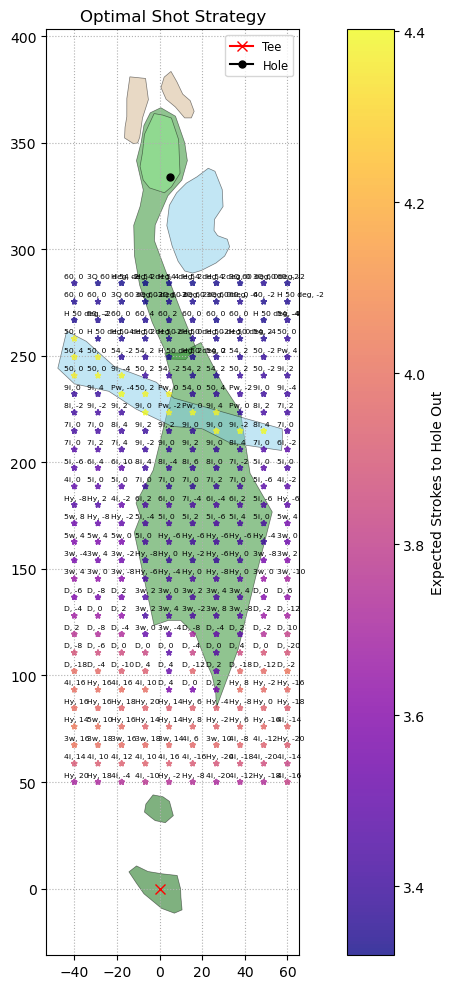

In [30]:
club_names = {
    'Driver':    {"short": "D",    "color": "#000000"},  # Black
    '3-wood':    {"short": "3w",   "color": "#FFAE00"},  # Orange
    '5-wood':    {"short": "5w",   "color": "#CC79A7"},  # Yellow
    'Hybrid':    {"short": "Hy",   "color": "#009E73"},  # Green
    '4 Iron':    {"short": "4i",   "color": "royalblue"},  # royal
    '5 Iron':    {"short": "5i",   "color": "#56B4E9"},  # Sky Blue
    '6 Iron':    {"short": "6i",   "color": "#4DAF4A"},  # Bright Green
    '7 Iron':    {"short": "7i",   "color": "#D55E00"},  # Reddish
    '8 Iron':    {"short": "8i",   "color": "#984EA3"},  # Purple
    '9 Iron':    {"short": "9i",   "color": "#FFEE00"},  # yellow
    'PW':        {"short": "Pw",   "color": "#0C034F"},  # Blue
    '50 deg':    {"short": "50",   "color": "#E41A1C"},  # Red
    '54 deg':    {"short": "54",   "color": "#999999"},  # Gray
    '60 deg':    {"short": "60",   "color": "#3E1F1F"},  # White
}


def plot_optimal_approaches(optimal_results, cmap="plasma", alpha=0.8, zorder=20):
    xs = [res["start"][0] for res in optimal_results]
    ys = [res["start"][1] for res in optimal_results]
    means = [res["mean"] for res in optimal_results]
    thin_space = "\u200B"
    labels = [f'{res["club"]},{thin_space}{res["aim_offset"]:+}y' for res in optimal_results]

    plt.figure(figsize=(20, 18))  # Try larger values!

    # Plot background
    plot_hole_layout(
        hole_geom_df=hole_9,
        new_fairway=new_fairway,
        new_hazards=[new_hazard3],
        tee_point=tee_point,
        hole_point=hole,
        title="Optimal Shot Strategy",
        plot_approach=False
    )

    labels = []
    for res in optimal_results:
        club_raw = res["club"]
        club_info = club_names.get(club_raw, {})  # Will be {} if not found
        short = club_info.get("short", club_raw)
        aim = int(res["aim_offset"]) if abs(res["aim_offset"] - int(res["aim_offset"])) < 1e-2 else res["aim_offset"]
        labels.append(f"{short}, {aim}")

    ax = plt.gca()
    scatter = ax.scatter(xs, ys, c=means, marker = (5,2), cmap=cmap, s=10, alpha=alpha, zorder=zorder)

    for i, (x, y, label) in enumerate(zip(xs, ys, labels)):
        if i % 1 == 0:  # Change 2 to another number for sparser labels
            ax.text(x - 5, y + 2.5, label, fontsize=5.5, color="black", zorder=zorder + 1)

    # Add colorbar for ESHO
    cbar = plt.colorbar(scatter, ax=ax, label="Expected Strokes to Hole Out")

    #plt.show()

plot_optimal_approaches(optimal_points)


<Figure size 2000x1800 with 0 Axes>

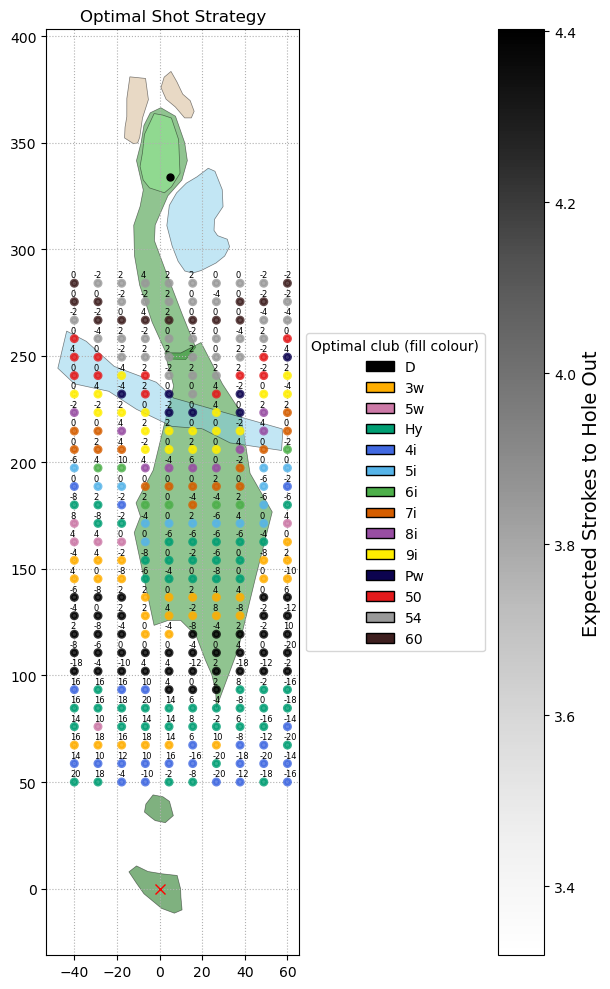

In [31]:
import matplotlib as mpl

def plot_optimal_approaches2(optimal_results, cmap="Greys", alpha=0.8, zorder=20):
    xs = [res["start"][0] for res in optimal_results]
    ys = [res["start"][1] for res in optimal_results]
    means = [res["mean"] for res in optimal_results]

   
    face_colors = []
    for res in optimal_results:
        club_raw = res["club"]
        club_info = club_names.get(club_raw, {"color": "#999999"})
        face_colors.append(club_info["color"])

    norm = mpl.colors.Normalize(vmin=min(means), vmax=max(means))
    cmap_obj = plt.get_cmap(cmap)
    # mean for edges
    edge_colors = [cmap_obj(norm(mean)) for mean in means]

    # buildin labels with only aim
    labels = []
    for res in optimal_results:
        club_raw = res["club"]
        club_info = club_names.get(club_raw, {"short": club_raw})
        short = club_info["short"]
        aim = int(res["aim_offset"]) if abs(res["aim_offset"] - int(res["aim_offset"])) < 1e-2 else res["aim_offset"]
        labels.append(f"{aim}")


    #plot hole
    plt.figure(figsize=(20, 18))
    plot_hole_layout(
        hole_geom_df=hole_9,
        new_fairway=new_fairway,
        new_hazards=[new_hazard3],
        tee_point=tee_point,
        hole_point=hole,
        title="Optimal Shot Strategy",
        plot_approach=False
    )

    # plot dots with face colors - club, edge colors, mean
    ax = plt.gca()
    scatter = ax.scatter(
        xs, ys,
        c=face_colors,
        s=20,
        alpha=alpha,
        zorder=zorder,
        linewidths=2,
        marker="o"
    )

    for x, y, label in zip(xs, ys, labels):
        ax.text(x-2, y + 2.7, label, fontsize=6, color="black", zorder=zorder + 1)

    # Colorbar for edge color (mean/ESHO)
    sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax)
    cbar.set_label("Expected Strokes to Hole Out", fontsize=14)

    # Club legend (for fill color)
    import matplotlib.patches as mpatches
    club_legend = [
    mpatches.Patch(facecolor=val["color"], edgecolor='k', label=val["short"])
    for val in club_names.values()
    ]
    ax.legend(
        handles=club_legend,
        title="Optimal club (fill colour)",
        loc="center left",
        bbox_to_anchor=(1, 0.5),
        fontsize=10
    )

    plt.subplots_adjust(right=4) 
plot_optimal_approaches2(optimal_points)
plt.show()


# Fitting a GPR to fairway points

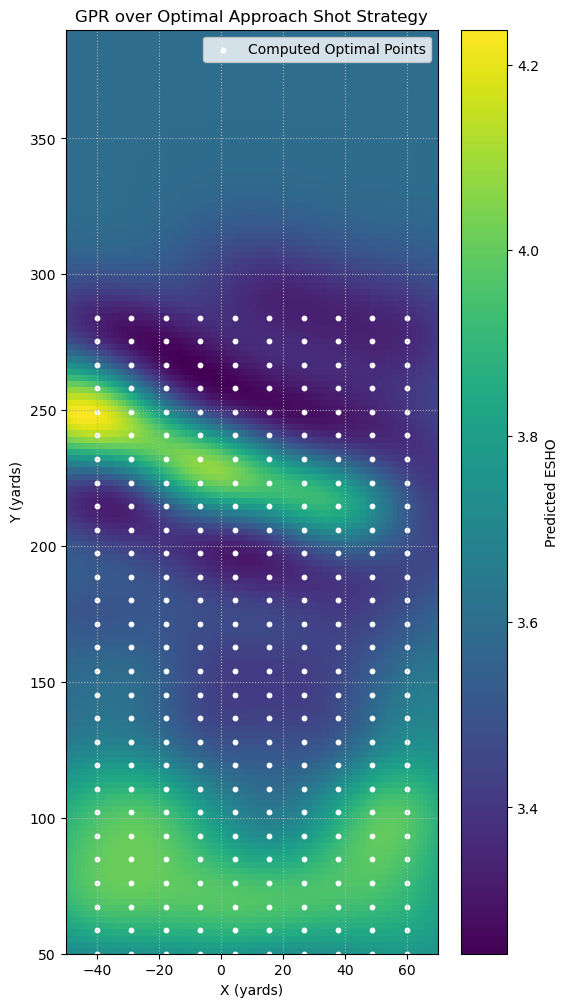

In [32]:
# X = coordinates, y = expected strokes
X_opt = torch.tensor([[res["start"][0], res["start"][1]] for res in optimal_points], dtype=torch.float32)
y_opt = torch.tensor([res["mean"] for res in optimal_points], dtype=torch.float32)

class GPModelApp(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super().__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel())
        self.covar_module.base_kernel.lengthscale = 15.0  # reasonable guess
        self.covar_module.base_kernel.raw_lengthscale.requires_grad = True
        

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)
    
likelihood_opt = gpytorch.likelihoods.GaussianLikelihood()
model_opt = GPModelApp(X_opt, y_opt, likelihood_opt)

model_opt.train()
likelihood_opt.train()

optimizer_opt = torch.optim.Adam(model_opt.parameters(), lr=0.1)
mll_opt = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood_opt, model_opt)

for i in range(100):
    optimizer_opt.zero_grad()
    output = model_opt(X_opt)
    loss = -mll_opt(output, y_opt)
    loss.backward()
    optimizer_opt.step()

model_opt.eval()
likelihood_opt.eval()

# Create prediction grid
xg = np.linspace(-50, 70, 100)
yg = np.linspace(50, 390, 150)
grid_points = torch.tensor([[x, y] for y in yg for x in xg], dtype=torch.float32)

with torch.no_grad(), gpytorch.settings.fast_pred_var():
    pred = likelihood_opt(model_opt(grid_points))
    pred_mean = pred.mean.reshape(len(yg), len(xg)).numpy()
    pred_std = pred.stddev.reshape(len(yg), len(xg)).numpy()

plt.figure(figsize=(6, 12))
plt.imshow(pred_mean, extent=[xg.min(), xg.max(), yg.min(), yg.max()],
           origin="lower", cmap="viridis", aspect="auto")
plt.colorbar(label="Predicted ESHO")
plt.scatter(X_opt[:, 0], X_opt[:, 1], c='white', s=10, label='Computed Optimal Points')
plt.legend()
plt.title("GPR over Optimal Approach Shot Strategy")
plt.xlabel("X (yards)")
plt.ylabel("Y (yards)")
plt.grid(True, linestyle=':')
plt.show()

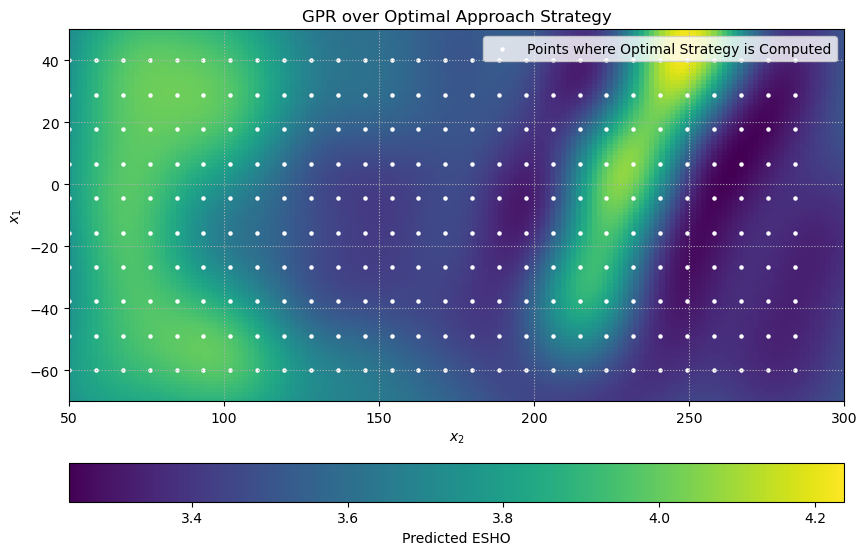

In [35]:
# ROTATED PLOT - GEMINI
import numpy as np
import matplotlib.pyplot as plt
from shapely import affinity

# --- Everything below replaces your evaluation/plotting code ---

# 1. Evaluate Model (Original Coordinates)
model_opt.eval()
likelihood_opt.eval()

# Define grid bounds (Original Space)
xg = np.linspace(-50, 70, 100)
yg = np.linspace(50, 300, 150)
xx, yy = np.meshgrid(xg, yg)
grid_points_flat = np.column_stack([xx.ravel(), yy.ravel()])
grid_tensor = torch.tensor(grid_points_flat, dtype=torch.float32)

# Predict
with torch.no_grad(), gpytorch.settings.fast_pred_var():
    pred = likelihood_opt(model_opt(grid_tensor))
    pred_mean = pred.mean.numpy()

# 2. Rotation Logic (Same as before)
rotation_angle = -90
theta = np.radians(rotation_angle)
c, s = np.cos(theta), np.sin(theta)
rotation_matrix = np.array(((c, -s), (s, c)))

# Rotate the Grid Points
grid_rotated = (rotation_matrix @ grid_points_flat.T).T
xx_rot = grid_rotated[:, 0].reshape(xx.shape)
yy_rot = grid_rotated[:, 1].reshape(yy.shape)

# Rotate the Scatter Points (Training Data)
X_opt_np = X_opt.numpy()
X_opt_rotated = (rotation_matrix @ X_opt_np.T).T

# 3. Plot
fig, ax = plt.subplots(figsize=(10, 8)) # Wider aspect ratio for rotated view

# Use pcolormesh instead of imshow to handle non-axis aligned grids
# shading='auto' or 'nearest' works best here
mesh = ax.pcolormesh(xx_rot, yy_rot, pred_mean.reshape(xx.shape), 
                     cmap="viridis", shading='auto')

# Plot the rotated training points
ax.scatter(X_opt_rotated[:, 0], X_opt_rotated[:, 1], c='white', s=5, 
            label='Points where Optimal Strategy is Computed')

# Auto-zoom based on rotated grid
ax.set_xlim(xx_rot.min(), xx_rot.max())
ax.set_ylim(yy_rot.min(), yy_rot.max())

# Formatting
ax.set_title(f"GPR over Optimal Approach Strategy")
ax.set_xlabel("$x_2$")
ax.set_ylabel("$x_1$")
ax.set_aspect('equal')
plt.grid(True, linestyle=':')

# Legend
ax.legend(loc='upper right')

# Horizontal Colorbar at the bottom
cbar = plt.colorbar(mesh, orientation='horizontal', pad=0.1)
cbar.set_label("Predicted ESHO")

plt.show()

In [36]:
original_hazard3 = new_hazard3.copy()  

def move_water(target_x3=0, target_y3=230):
    original_centroid = original_hazard3.iloc[0].geometry.centroid
    x3_shift = target_x3 - original_centroid.x
    y3_shift = target_y3 - original_centroid.y

    new_hazard3["geometry"] = original_hazard3["geometry"].apply(
        lambda geom: translate(geom, xoff=x3_shift, yoff=y3_shift)
    )
    polygon_redefiner()
    return new_hazard3["geometry"]

def evaluate_tee_shot(tee_point, gpr_model, gpr_likelihood, aim_range=(-20, 20), aim_step=2, n_samples=30, n_water = False):

    if n_water:
            polygon_redefiner()
    
    best = None
    aim_offsets = range(aim_range[0], aim_range[1] + 1, aim_step)
    
    results = []

    for club in club_distributions:
        for aim in aim_offsets:
            mu, cov = get_club_distribution(club)
            samples = np.random.multivariate_normal(mu, cov, size=n_samples)

            evaluated_strokes = []

            for shot in samples:
                # Rotate to global coordinates
                x_rot, y_rot = rotation_translator2(shot[0], shot[1], aim, tee_point, hole)

                # Predict ESHO from the GPR model
                input_tensor = torch.tensor([[x_rot, y_rot]], dtype=torch.float32)
                with torch.no_grad(), gpytorch.settings.fast_pred_var():
                    pred = gpr_likelihood(gpr_model(input_tensor))
                    esho = pred.mean.item()

                if not np.isnan(esho):
                    evaluated_strokes.append(esho)

            if evaluated_strokes:
                mean_esho = np.mean(evaluated_strokes)
                var_esho = np.var(evaluated_strokes)

                result = {
                    "club": club,
                    "aim_offset": aim,
                    "mean": mean_esho,
                    "variance": var_esho
                }

                results.append(result)

                if (best is None) or (mean_esho < best["mean"]):
                    best = result

    return best, results

best_tee_shot, all_tee_shots = evaluate_tee_shot(tee_point=tee_point, gpr_model=model_opt, gpr_likelihood=likelihood_opt, aim_range=(-30,30), aim_step=2, n_samples=50)

print(best_tee_shot)

{'club': '5-wood', 'aim_offset': 0, 'mean': 3.4138769721984863, 'variance': 0.0063095808167289765}


<>:93: SyntaxWarning: invalid escape sequence '\S'
<>:93: SyntaxWarning: invalid escape sequence '\S'
/var/folders/vr/34gvhdpn06z_plwsw13j8w4c0000gn/T/ipykernel_72810/183766998.py:93: SyntaxWarning: invalid escape sequence '\S'
  callout_text = f"BEST DECISION\Shot/Club: {club_tee}\nOffset Aim Relative to Pin: {offset_tee:+}y"


<Figure size 2000x1000 with 0 Axes>

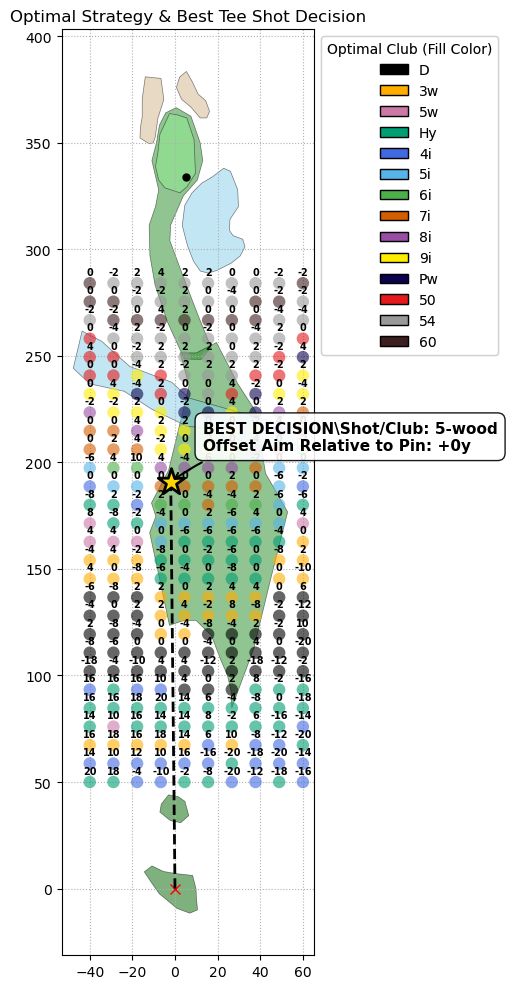

In [64]:
## Joined GEMINI
import matplotlib.patches as mpatches

def plot_combined_strategy(optimal_results, best_tee_shot, club_names, 
                           tee_point, hole_point, hole_geom_df, new_fairway, new_hazards,
                           cmap="Greys", alpha=0.8, zorder=20):
    
    # --- 1. PREPARE DATA FOR OPTIMAL APPROACHES ---
    xs = [res["start"][0] for res in optimal_results]
    ys = [res["start"][1] for res in optimal_results]
    means = [res["mean"] for res in optimal_results]

    face_colors = []
    labels = []
    
    for res in optimal_results:
        # Determine Face Color (Club)
        club_raw = res["club"]
        club_info = club_names.get(club_raw, {"color": "#999999", "short": club_raw})
        face_colors.append(club_info["color"])
        
        # Determine Label (Aim Offset)
        aim = res["aim_offset"]
        # Format aim cleanly (integer if close to int, otherwise 1 decimal)
        if abs(aim - int(round(aim))) < 1e-2:
            label_str = f"{int(round(aim))}"
        else:
            label_str = f"{aim:.1f}"
        labels.append(label_str)

    # Determine Edge Color (Expected Strokes)
    norm = mpl.colors.Normalize(vmin=min(means), vmax=max(means))
    cmap_obj = plt.get_cmap(cmap)
    edge_colors = [cmap_obj(norm(m)) for m in means]

    # --- 2. SETUP PLOT & BACKGROUND ---
    plt.figure(figsize=(20, 10))
    
    # Plot the hole layout (assuming this function exists in your scope)
    plot_hole_layout(
        hole_geom_df=hole_geom_df,
        new_fairway=new_fairway,
        new_hazards=new_hazards,
        tee_point=tee_point,
        hole_point=hole_point,
        title="Optimal Strategy & Best Tee Shot Decision",
        plot_approach=False
    )
    ax = plt.gca()

    # --- 3. PLOT OPTIMAL APPROACH POINTS ---
    # Dots: Face = Club Color, Edge = Expected Strokes (Mean)
    ax.scatter(
        xs, ys,
        c=face_colors,
        edgecolors=edge_colors,
        s=80,          # Slightly larger to make edge colors visible
        linewidths=0, # Thicker edges for better visibility
        alpha=.6,
        zorder=zorder,
        marker="o"
    )

    # Add Aim Labels near dots
    for x, y, label in zip(xs, ys, labels):
        ax.text(x, y + 3, label, fontsize=7, color="black", 
                ha='center', va='bottom', zorder=zorder + 1, fontweight='bold')

    # --- 4. CALCULATE & PLOT BEST TEE SHOT ---
    # Unpack best shot details
    club_tee = best_tee_shot["club"]
    offset_tee = best_tee_shot["aim_offset"]

    # Calculate landing location (assuming these objects exist in your scope)
    mu = club_distributions[club_tee]["mean"]
    x_rot, y_rot = rotation_translator2(
        mu[0], mu[1],
        offset_tee,
        starting_point=tee_point,
        target=hole_point
    )

    # A. Connector Line (Origin to Landing)
    ax.plot([tee_point[0], x_rot], [tee_point[1], y_rot], 
            color='black', linestyle='--', linewidth=2, zorder=zorder+5, label="Tee Shot Line")

    # B. Landing Marker (Large Star)
    ax.scatter([x_rot], [y_rot], 
               color="gold", edgecolors='black', linewidth=2, s=400, 
               marker="*", zorder=zorder+6, label="Best Tee Shot Landing")

    # C. Strong Callout Label
    callout_text = f"BEST DECISION\Shot/Club: {club_tee}\nOffset Aim Relative to Pin: {offset_tee:+}y"
    ax.annotate(
        callout_text, 
        xy=(x_rot, y_rot), 
        xytext=(x_rot + 15, y_rot + 15), # Offset text slightly up-right
        textcoords='data',
        fontsize=11, fontweight='bold', color='black',
        bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="black", alpha=0.9),
        arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=.2", color="black", lw=1.5),
        zorder=zorder+10
    )

    # --- 5. LEGENDS & COLORBARS ---


    # Club Legend (Fill Color)
    club_patches = [
        mpatches.Patch(facecolor=val["color"], edgecolor='k', label=val["short"])
        for val in club_names.values()
    ]
    
    # We add two legends: one for clubs, one for the tee shot elements
    # 1. Club Legend
    legend1 = ax.legend(
        handles=club_patches,
        title="Optimal Club (Fill Color)",
        loc="upper left",
        bbox_to_anchor=(1, 1),
        fontsize=10,
        frameon=True
    )
    ax.add_artist(legend1) # Add manually so we can create a second legend
    plt.subplots_adjust(right=0.85) # Make room for the side legend
    plt.show()

# Run the function
plot_combined_strategy(
    optimal_results=optimal_points, 
    best_tee_shot=best_tee_shot, 
    club_names=club_names, 
    tee_point=tee_point, 
    hole_point=hole, 
    hole_geom_df=hole_9, 
    new_fairway=new_fairway, 
    new_hazards=[new_hazard3]
)

<Figure size 1200x1800 with 0 Axes>

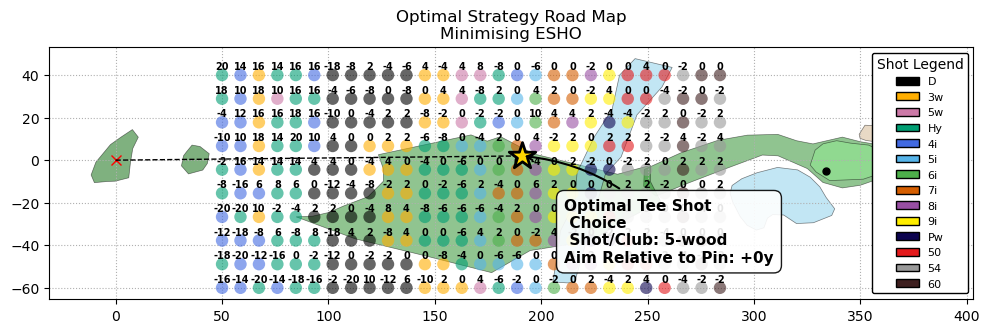

In [96]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from shapely import affinity, wkt
import pandas as pd
import geopandas as gpd

def plot_combined_strategy_rotated_cw(optimal_results, best_tee_shot, club_names, 
                                      tee_point, hole_point, hole_geom_df, new_fairway, new_hazards,
                                      cmap="Greys", alpha=0.6, zorder=20):

    # --- 0. ROTATION HELPERS (-90 Degrees) ---
    def rotate_xy(x, y):
        # -90 degrees (Clockwise): (x, y) -> (y, -x)
        return y, -x

    def rotate_geom(geom_input):
        if geom_input is None: return None

        # Extract geometry if input is a DataFrame/Series
        if hasattr(geom_input, 'geometry'):
            # If GeoDataFrame, grab the first geometry
            if hasattr(geom_input.geometry, 'iloc'):
                g = geom_input.geometry.iloc[0]
            else:
                g = geom_input.geometry
        elif hasattr(geom_input, 'columns') and 'WKT' in geom_input.columns:
            g = geom_input['WKT'].iloc[0]
        else:
            g = geom_input

        # Ensure it's a Shapely object
        g_obj = wkt.loads(g) if isinstance(g, str) else g
        
        # Rotate -90 deg around origin (0,0)
        return affinity.rotate(g_obj, -90, origin=(0, 0))

    # --- 1. ROTATE INPUTS ---
    # Rotate Points
    tee_rot = rotate_xy(tee_point[0], tee_point[1])
    hole_rot = rotate_xy(hole_point[0], hole_point[1])

    # Rotate Geometry Dataframe
    hole_geom_rot = hole_geom_df.copy()
    hole_geom_rot['WKT'] = hole_geom_rot['WKT'].apply(lambda g: rotate_geom(g).wkt)

    # Rotate New Features & Wrap in GeoDataFrame
    # 1. Fairway
    fairway_poly_rot = rotate_geom(new_fairway)
    if fairway_poly_rot is not None:
        new_fairway_rot = gpd.GeoDataFrame({'geometry': [fairway_poly_rot]})
    else:
        new_fairway_rot = None

    # 2. Hazards
    new_hazards_rot = []
    if new_hazards:
        for h in new_hazards:
            h_rot_poly = rotate_geom(h)
            if h_rot_poly:
                new_hazards_rot.append(gpd.GeoDataFrame({'geometry': [h_rot_poly]}))

    # --- 2. PREPARE OPTIMAL APPROACH DATA ---
    xs_rot = []
    ys_rot = []
    means = []
    face_colors = []
    labels = []

    for res in optimal_results:
        rx, ry = rotate_xy(res["start"][0], res["start"][1])
        xs_rot.append(rx)
        ys_rot.append(ry)
        means.append(res["mean"])

        club_raw = res["club"]
        club_info = club_names.get(club_raw, {"color": "#999999", "short": club_raw})
        face_colors.append(club_info["color"])
        
        aim = res["aim_offset"]
        if abs(aim - int(round(aim))) < 1e-2:
            labels.append(f"{int(round(aim))}")
        else:
            labels.append(f"{aim:.1f}")

    # --- 3. PREPARE BEST TEE SHOT ---
    club_tee = best_tee_shot["club"]
    offset_tee = best_tee_shot["aim_offset"]
    
    mu = club_distributions[club_tee]["mean"]
    orig_land_x, orig_land_y = rotation_translator2(
        mu[0], mu[1], offset_tee, starting_point=tee_point, target=hole_point
    )
    best_land_x_rot, best_land_y_rot = rotate_xy(orig_land_x, orig_land_y)

    # --- 4. PLOT ---
    plt.figure(figsize=(12, 18))
    
    plot_hole_layout(
        hole_geom_df=hole_geom_rot,
        new_fairway=new_fairway_rot, 
        new_hazards=new_hazards_rot,
        tee_point=tee_rot,
        hole_point=hole_rot,
        title="Optimal Strategy Road Map\nMinimising ESHO",
        plot_approach=False
    )
    ax = plt.gca()

    # Scatter Points
    ax.scatter(
        xs_rot, ys_rot,
        c=face_colors,
        s=80,
        linewidths=0,
        alpha=alpha,
        zorder=zorder,
        marker="o"
    )

    # Labels (Offset to the right)
    for x, y, label in zip(xs_rot, ys_rot, labels):
        ax.text(x, y+4, label, fontsize=7, color="black",
                ha='center', va='center', zorder=zorder + 1, fontweight='bold')

    # Best Tee Shot Elements
    ax.plot([tee_rot[0], best_land_x_rot], [tee_rot[1], best_land_y_rot], 
            color='black', linestyle='--', linewidth=1, zorder=zorder+5)

    ax.scatter([best_land_x_rot], [best_land_y_rot], 
               color="gold", edgecolors='black', linewidth=2, s=400, 
               marker="*", zorder=zorder+6)

    callout_text = f"Optimal Tee Shot\n Choice\n Shot/Club: {club_tee}\nAim Relative to Pin: {offset_tee:+}y"
    ax.annotate(
        callout_text, 
        xy=(best_land_x_rot, best_land_y_rot), 
        xytext=(best_land_x_rot + 20, best_land_y_rot - 50), # Text to the right of star
        textcoords='data',
        fontsize=11, fontweight='bold', color='black',
        bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="black", alpha=0.9),
        arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=.2", color="black", lw=1.5),
        zorder=zorder+10
    )

    # Legend
    club_patches = [
        mpatches.Patch(facecolor=val["color"], edgecolor='k', label=val["short"])
        for val in club_names.values()
    ]
    
    ax.legend(
        handles=club_patches,
        title="Shot Legend",
        loc="upper right",
        bbox_to_anchor=(1, 1),
        fontsize=8,
        framealpha=1.0,
        edgecolor='black'
    )
    
    ax.autoscale_view()
    ax.set_aspect('equal')
    plt.tight_layout()
    plt.show()

# Run the function
plot_combined_strategy_rotated_cw(
    optimal_results=optimal_points, 
    best_tee_shot=best_tee_shot, 
    club_names=club_names, 
    tee_point=tee_point, 
    hole_point=hole, 
    hole_geom_df=hole_9, 
    new_fairway=new_fairway, 
    new_hazards=[new_hazard3]
)

<Figure size 2000x1800 with 0 Axes>

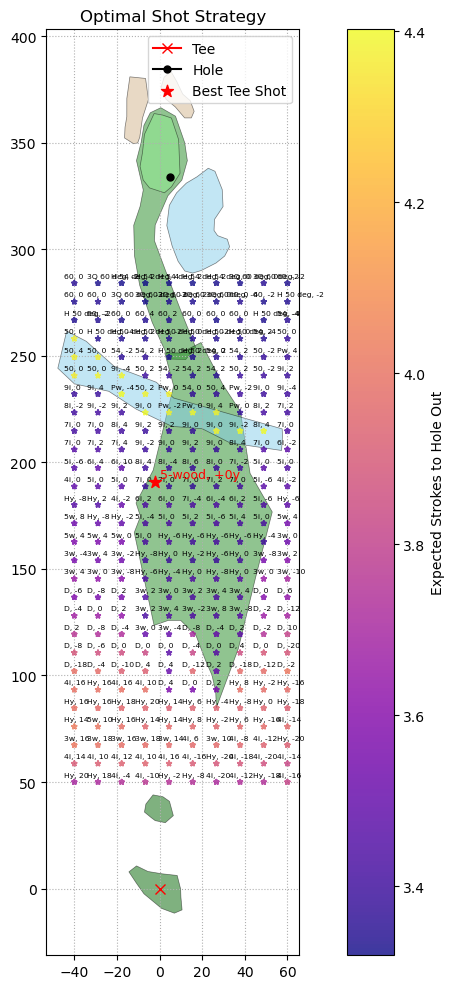

In [44]:
def plot_best_tee_shot(best_tee_shot, title="Best Tee Shot Overlay", zorder=100000, n_water = False, optimal_points = optimal_points):

    if n_water:
        polygon_redefiner()
    

    # Unpack best shot details
    club = best_tee_shot["club"]
    offset = best_tee_shot["aim_offset"]

    # Get mean shot shape for the club
    mu = club_distributions[club]["mean"]

    # Compute rotated landing location
    x_rot, y_rot = rotation_translator2(
        mu[0], mu[1],
        offset,
        starting_point=tee_point,
        target=hole
    )


    # Plot hole background
    # plot_hole_layout(
    #     hole_geom_df=hole_9,
    #     new_fairway=new_fairway,
    #     new_hazards=[new_hazard3],
    #     tee_point=tee_point,
    #     hole_point=hole,
    #     title=title,
    #     plot_approach=True
    # )
    plot_optimal_approaches(optimal_points)

    ax = plt.gca()

    # Plot best tee shot landing location
    ax.scatter([x_rot], [y_rot], color="red", s=80, marker="*", label="Best Tee Shot", zorder=zorder)

    # Annotate with club and aim offset
    label_text = f'{club}, {offset:+}y'
    ax.text(x_rot + 2, y_rot + 2, label_text, fontsize=9, color="red", zorder=zorder + 1)

    ax.legend(loc="upper right")
    plt.show()

plot_best_tee_shot(best_tee_shot)

## Moving Water

<Axes: title={'center': 'Par 4 Strategy Layout'}>

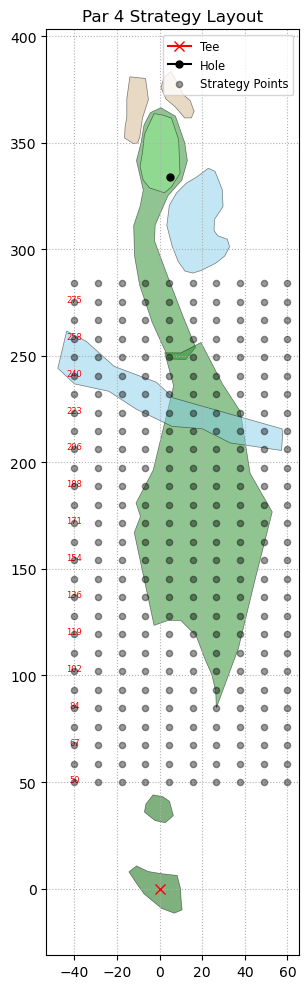

In [39]:
    
# maybe for parallel
def move_water2(target_x3=0, target_y3=230):
    original_centroid = original_hazard3.iloc[0].geometry.centroid
    x3_shift = target_x3 - original_centroid.x
    y3_shift = target_y3 - original_centroid.y

    shifted = original_hazard3.copy()
    shifted["geometry"] = shifted["geometry"].apply(
        lambda geom: translate(geom, xoff=x3_shift, yoff=y3_shift)
    )
    water_polygons = get_polygons(hole_9, "water") + list(shifted["geometry"])
    return shifted


plot_hole_layout(
    hole_geom_df=hole_9,
    new_fairway=new_fairway,
    new_hazards=[new_hazard3],
    tee_point=tee_point,
    hole_point=hole,
    title="Par 4 Strategy Layout",
    plot_approach= True
)

In [40]:
def run_simulation_for_water(target_x3, target_y3, n_samples = 20 ,save_prefix=True, n_water = True):
    # Move the water hazard
    new_hazard3["geometry"] = move_water(target_x3, target_y3)

    polygon_redefiner()
    # global water_polygons

    # water_polygons = get_polygons(hole_9, "water") + list(new_hazard3["geometry"])

    # Simulate optimal approach shots
    optimal_points_approach = simulate_approach_shots(
        starting_points=strategy_points,
        clubs=list(club_distributions.keys()),
        target=hole,
        aim_range=(-20, 20),
        aim_step=2,
        n_samples=n_samples
    )

    # Fit Gaussian Process Regression model for approach shots
    X_opt = torch.tensor([[res["start"][0], res["start"][1]] for res in optimal_points_approach], dtype=torch.float32)
    y_opt = torch.tensor([res["mean"] for res in optimal_points_approach], dtype=torch.float32)

    aplikelihood = gpytorch.likelihoods.GaussianLikelihood()
    apmodel = GPModelApp(X_opt, y_opt, aplikelihood)

    apmodel.train()
    aplikelihood.train()
    optimizer = torch.optim.Adam(apmodel.parameters(), lr=0.1)
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(aplikelihood, apmodel)

    for _ in range(50):
        optimizer.zero_grad()
        output = apmodel(X_opt)
        loss = -mll(output, y_opt)
        loss.backward()
        optimizer.step()

    apmodel.eval()
    aplikelihood.eval()

    # Evaluate tee shot strategy
    best_tee_shot, _ = evaluate_tee_shot(
        tee_point=tee_point,
        gpr_model=apmodel,
        gpr_likelihood=aplikelihood,
        aim_range=(-10, 10),
        aim_step=2,
        n_samples=n_samples,
        n_water=n_water
    )

    # Plot results
    plot_optimal_approaches(optimal_points_approach)
    plot_best_tee_shot(best_tee_shot, title=f"Tee Shot (Water at {target_x3},{target_y3})", n_water=True, optimal_points=optimal_points_approach)

    if save_prefix:
        plt.savefig(f"{save_prefix}_strategy.png", dpi=300)
        plt.close()

    return best_tee_shot


# Moving the water 

Running simulation for water at (0, 100)...


/opt/anaconda3/lib/python3.12/site-packages/shapely/set_operations.py:131: RuntimeWarning: invalid value encountered in intersection
  return lib.intersection(a, b, **kwargs)


<Figure size 2000x1800 with 0 Axes>

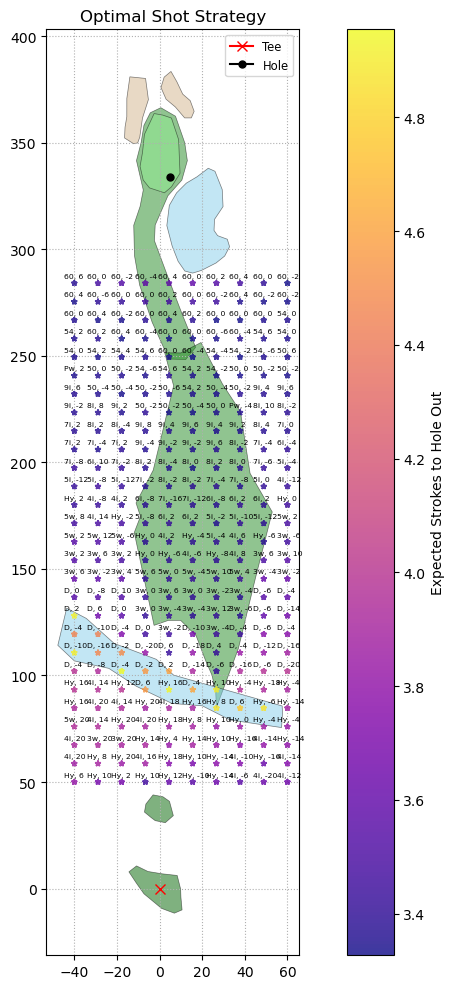

<Figure size 2000x1800 with 0 Axes>

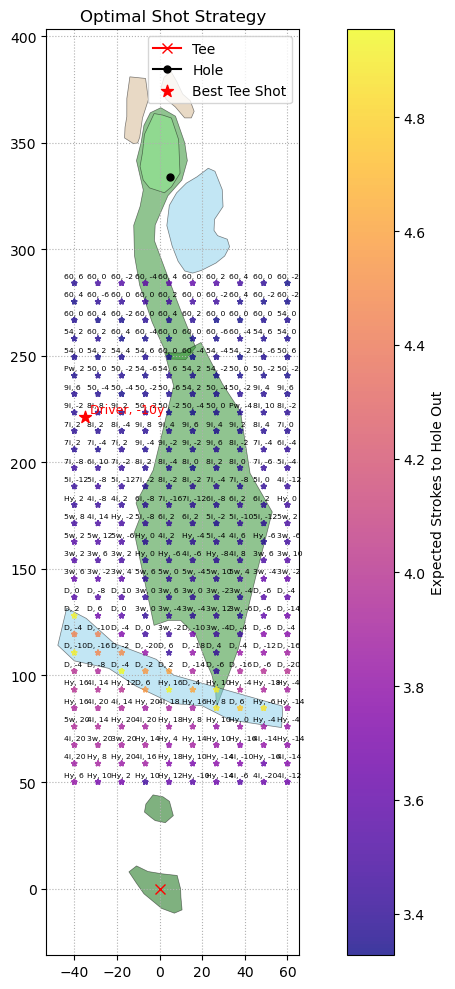

In [106]:
water_targets = [
    (0, 100)
]

results = []

for x, y in water_targets:
    print(f"Running simulation for water at ({x}, {y})...")
    result = run_simulation_for_water(x, y, n_samples=20, save_prefix=f"sim_{x}_{y}")
    results.append(result)


In [113]:
!jupyter nbconvert --to script par4model.ipynb

[NbConvertApp] Converting notebook par4model.ipynb to script
[NbConvertApp] Writing 41414 bytes to par4model.py


In [112]:
from multiprocessing import get_context

def run_simulation_wrapper(args):
    x, y = args
    print(f"Running simulation for water at ({x}, {y})...")
    return run_simulation_for_water(x, y, n_samples=5, save_prefix=f"sim_{x}_{y}")

# Generate all (0, y) targets
water_targets = [(0, y) for y in range(100, 331, 10)]
water_targets = [(0, y) for y in range(100, 131, 10)] 
print(water_targets)

# Use the 'spawn' context which is safer for Jupyter
ctx = get_context("spawn")
with ctx.Pool(processes=3) as pool:  # Adjust number of cores if needed
    results = pool.map(run_simulation_wrapper, water_targets)


[(0, 100), (0, 110), (0, 120), (0, 130)]


Process SpawnPoolWorker-9:
Process SpawnPoolWorker-10:
Process SpawnPoolWorker-8:
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.12/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/opt/anaconda3/lib/python3.12/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/opt/anaconda3/lib/python3.12/multiprocessing/pool.py", line 114, in worker
    task = get()
           ^^^^^
  File "/opt/anaconda3/lib/python3.12/multiprocessing/queues.py", line 389, in get
    return _ForkingPickler.loads(res)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.12/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
AttributeError: Can't get attribute 'run_simulation_wrapper' on <module '__main__' (<class '_frozen_importlib.BuiltinImporter'>)>
  File "/opt/anaconda3/lib/python3.12/multiprocessing/process.py

KeyboardInterrupt: 

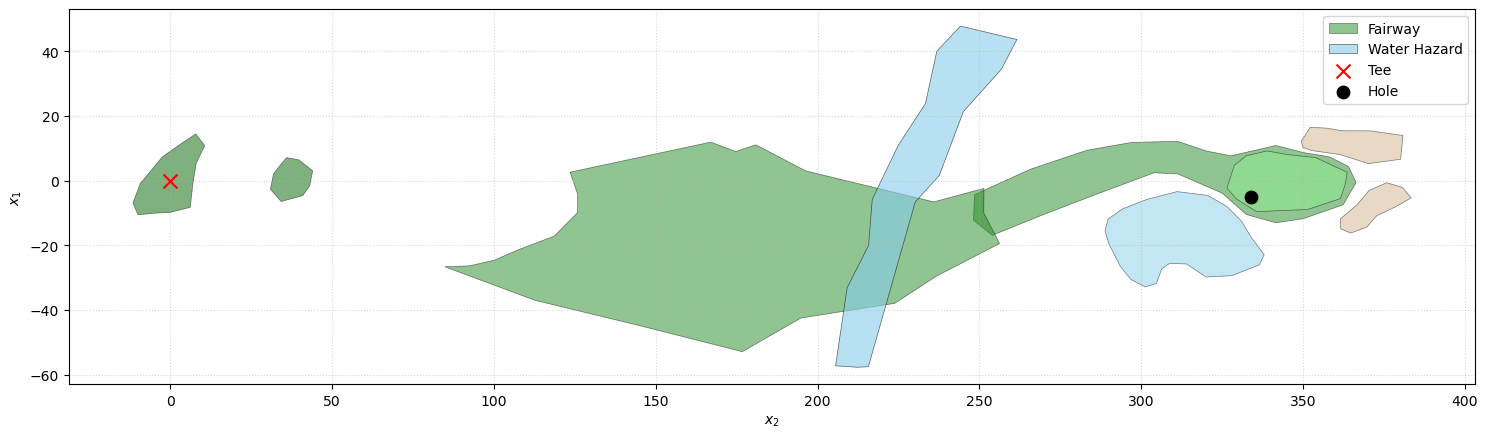

In [104]:
import matplotlib.pyplot as plt
from shapely import wkt
import numpy as np

def plot_hole_layout_rotated_corrected(hole_geom_df, new_fairway, new_hazards, tee_point, hole_point):
    
    # --- 1. Define Original Color Scheme ---
    lie_colors = {
        "bunker": "tan",
        "fairway": "forestgreen",
        "new_fairway": "forestgreen",
        "green": "lightgreen",
        "OB": "lightcoral",
        "rough": "mediumseagreen",
        "tee": "darkgreen",
        "water_hazard": "skyblue",
        "new_hazard1": "skyblue",
        "new_hazard2": "skyblue",
        "new_hazard3": "skyblue"
    }

    fig, ax = plt.subplots(figsize=(15, 8))

    # --- 2. ROTATION HELPER (True -90 Degree Rotation) ---
    # Transformation: (x, y) -> (y, -x)
    # This ensures "Left" in the vertical view becomes "Top" in horizontal view, preserving orientation.
    def get_rotated_coords(geom):
        if geom is None: return [], []
        
        # Robustly handle Polygon vs MultiPolygon
        if geom.geom_type == 'Polygon':
            xs, ys = geom.exterior.xy
        elif geom.geom_type == 'MultiPolygon':
            xs, ys = geom.geoms[0].exterior.xy 
        else:
            return [], []
            
        # Convert to numpy arrays for easy element-wise operation
        xs = np.array(xs)
        ys = np.array(ys)
        
        # --- THE FIX IS HERE ---
        # New X = Old Y
        # New Y = Negative Old X
        return ys, -xs 

    # --- 3. PLOT GEOMETRY ---
    
    # Plot Base Hole Layers
    for _, row in hole_geom_df.iterrows():
        g = wkt.loads(row['WKT'])
        rx, ry = get_rotated_coords(g)
        c = lie_colors.get(row['lie'], "lightgrey")
        ax.fill(rx, ry, color=c, alpha=0.5, ec='black', lw=0.5)

    # Plot New Fairway
    if new_fairway is not None:
        geom = new_fairway.geometry.iloc[0] if hasattr(new_fairway, "geometry") else new_fairway
        fx, fy = get_rotated_coords(geom)
        ax.fill(fx, fy, color=lie_colors['new_fairway'], alpha=0.5, ec='black', lw=0.5, label='Fairway')

    # Plot New Hazards
    for i, haz in enumerate(new_hazards):
        if haz is not None:
            geom = haz.geometry.iloc[0] if hasattr(haz, "geometry") else haz
            hx, hy = get_rotated_coords(geom)
            
            # Get color key
            haz_key = f"new_hazard{i+3}"
            c = lie_colors.get(haz_key, lie_colors['water_hazard'])
            
            ax.fill(hx, hy, color=c, alpha=0.6, ec='black', lw=0.5, label='Water Hazard')

    # --- 4. PLOT TEE & HOLE ---
    # Apply the same rotation formula: (y, -x)
    tee_x_rot = tee_point[1]
    tee_y_rot = -tee_point[0]
    
    hole_x_rot = hole_point[1]
    hole_y_rot = -hole_point[0]

    ax.scatter(tee_x_rot, tee_y_rot, marker='x', color='red', s=100, zorder=10, label="Tee")
    ax.scatter(hole_x_rot, hole_y_rot, marker='o', color='black', s=80, zorder=10, label="Hole")

    # --- 5. FORMATTING ---
    ax.set_aspect('equal')
    plt.title("", fontsize=14)
    plt.xlabel("$x_2$")
    plt.ylabel("$x_1$")
    
    # Legend deduplication
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), loc='upper right')
    
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.tight_layout()
    plt.show()

# Run it
plot_hole_layout_rotated_corrected(
    hole_geom_df=hole_9, 
    new_fairway=new_fairway, 
    new_hazards=[new_hazard3], 
    tee_point=tee_point, 
    hole_point=hole
)